# Exercise 4.A Introduction to Linear Regression

In [4]:
#importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

## Lab 1
### Running a sample script

In [7]:
# Sample dataset: hours studied vs. exam score
data = {
    'hours_studied': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'exam_score':    [52, 55, 60, 65, 68, 72, 75, 80, 85, 90]
}
df = pd.DataFrame(data)

# Step 1: Define features (X) and target (y)
X = df[['hours_studied']]   # 2D: double brackets give a DataFrame, not a Series
y = df['exam_score']        # 1D: single brackets give a Series

# Step 2: Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 3: Create the model and fit it to training data
model = LinearRegression()
model.fit(X_train, y_train)

print('Model trained successfully.')

Model trained successfully.


### Working through the sample script

In [10]:
#printing the slope and intercept
print(f'\nSlope (coefficient): {model.coef_[0]:.2f}')
print(f'Intercept: {model.intercept_:.2f}')


Slope (coefficient): 4.10
Intercept: 47.68


In [14]:
# making predictions
y_pred = model.predict(X_test)
print('Actual scores: ',list(y_test))
print('Predicted scores:',list(y_pred.round(1)))

Actual scores:  [85, 55]
Predicted scores: [84.6, 55.9]


### Observation:
The actual score is 85 and 55, while the model prediction is 84.6 and 55.9.
Based on this observation, the model prediction is not that far off with 0.4 and 0.9, close to exact values.
This displayed that the linear regression model learned the pattern to make the predictions accurately.

In [17]:
#evaluating variation using R-squared
r_squared = model.score(X_test,y_test)
print(f'R² score: {r_squared:.3f}') #displaying ouput rounded 3 decimal places

R² score: 0.998


### R² Observation:
The R² score is 0.998. This showed that the model is able to exaplin almost all the changes
in the exam score based on the hours studied (X). The score being very high shows the model
fits the data very well.

C:\Users\chimm\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


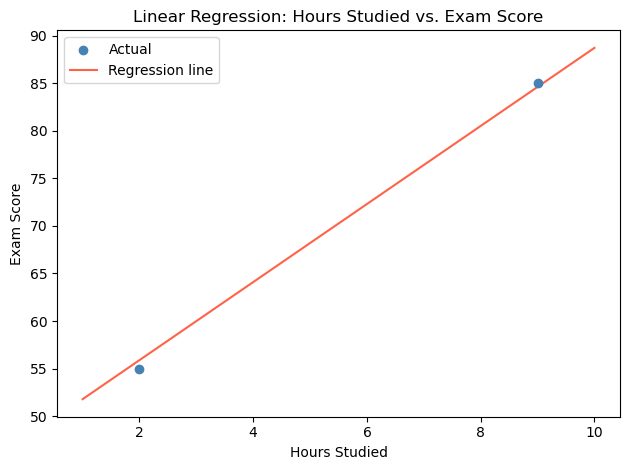

In [24]:
#visualizing regression line

# Scatter plot: actual test data points
plt.scatter(X_test, y_test, color='steelblue', label='Actual', zorder=3)

# Line: model predictions across the full range of X
x_range = np.linspace(
    X['hours_studied'].min(),
    X['hours_studied'].max(),
    100).reshape(-1, 1)
y_line = model.predict(x_range)
plt.plot(x_range, y_line, color='tomato', label='Regression line')

plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.title('Linear Regression: Hours Studied vs. Exam Score')
plt.legend()
plt.tight_layout()
plt.show()

### Regression Line Observation:
The blue dots represent the actual test data points, and they very close to the red regression line.
The graph displays that the model fits the data, because the points are displayed going along
the line (upward along the line). We can see that the hours studied increasing, also made the exams scores increase.
This visual shows there is a trend between the two.

## Lab 2
### Building your own model

In [28]:
#creating a df for ad and revenue
ad_data = {
    'monthly_ad_spend': [500, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500,
                         5000, 5500, 6000, 6500, 7000, 7500, 8000, 8500, 9000,
                         9500, 10000],
    'monthly_revenue': [4200, 5100, 6800, 7400, 8900, 9200, 10500, 11800,
                        12400, 13100, 14200, 15600, 15900, 17200, 18100, 
                        19400, 20200, 21500, 22100, 23800]}

#creating df
df_ads = pd.DataFrame(ad_data)
df_ads #displaying output

,monthly_ad_spend,monthly_revenue
0,500,4200
1,1000,5100
2,1500,6800
3,2000,7400
4,2500,8900
5,3000,9200
6,3500,10500
7,4000,11800
8,4500,12400
9,5000,13100


In [30]:
#defining feature matrix (X2) and target vector (y2)

X2 = df_ads[['monthly_ad_spend']] #keeping as DataFrame
y2 = df_ads['monthly_revenue'] #Series

#printing shapes
print(X2.shape)
print(y2.shape)

(20, 1)
(20,)


In [32]:
#splitting X2 & y2 into training and test sets
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42)

#printing shapes
print(X2_train.shape)
print(X2_test.shape)
print(y2_train.shape)
print(y2_test.shape)

(16, 1)
(4, 1)
(16,)
(4,)


In [36]:
#creating LinearRegression model for training data
model2 = LinearRegression()
model2.fit(X2_train, y2_train)

print("Model trained successfully.")

Model trained successfully.


In [40]:
#printing slope and intercept for model2
print(f"Slope (coefficient): {model2.coef_[0]:.2f}")
print(f"Intercept: {model2.intercept_:.2f}")

Slope (coefficient): 1.96
Intercept: 3625.89


#### Interpretation:
The slope being at 1.96 shows that every dollar spent on ads, the predicted monthly revenue increases about 1.96 dollars.
The intercept of 3625.89, shows the predicted revenue when 0 dollars are spent on ads.

### Making predictions and evaluating the model

In [45]:
#making prediction for revenue
y2_pred = model2.predict(X2_test)

#printing actual vs predicted
print("Actual values: ",list(y2_test))
print("Predicted values: ",list(y2_pred.round(2)))

Actual values:  [4200, 21500, 19400, 5100]
Predicted values:  [4603.85, 21229.03, 19273.13, 5581.8]


In [47]:
#calculating R-squared for model2
r2_score = model2.score(X2_test,y2_test)
print(f"R² score: {r2_score:.3f}")

R² score: 0.998


### R² Interpretation:
The R² score for model2 is 0.998, displaying 99.8% of the changes in revenue
can be explained for the amount of money spent on ads.
With the number being so high, it shows that the model is a very good fit.

### Visualizing the results

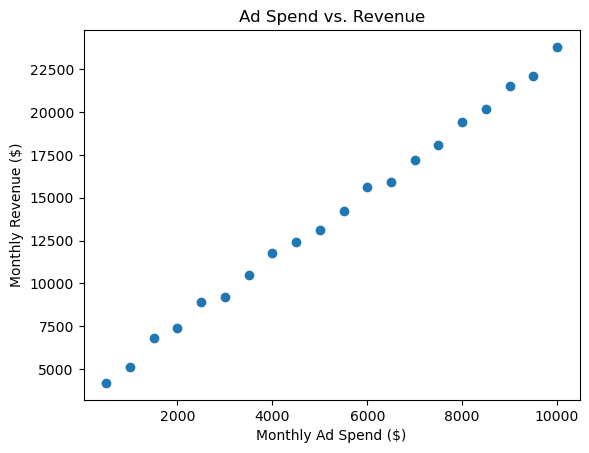

In [53]:
#creating a scatter plot for full dataset (dots only)
plt.scatter(X2,y2)

#creating title and labels
plt.title('Ad Spend vs. Revenue')
plt.xlabel('Monthly Ad Spend ($)')
plt.ylabel('Monthly Revenue ($)')

#displaying output
plt.show()

C:\Users\chimm\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


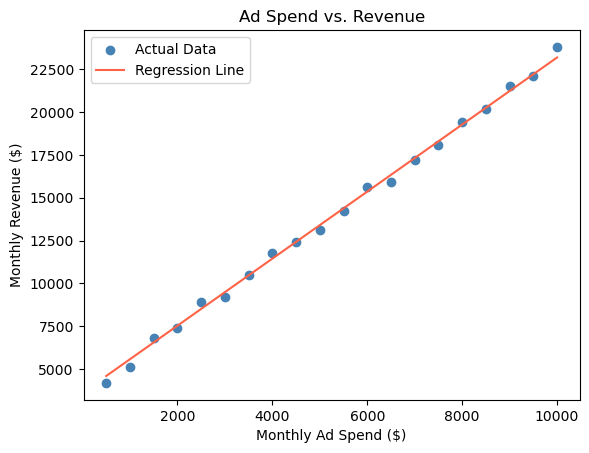

In [59]:
#scatter plot with regression line added
plt.scatter(X2,y2, color='steelblue', label='Actual Data')

#creating range for X values
x_range = np.linspace(X2.min(),X2.max(),100).reshape(-1,1)
y_line = model2.predict(x_range)

#plotting regression line
plt.plot(x_range,y_line, color='tomato', label='Regression Line')

#creating title and labels and legend
plt.title('Ad Spend vs. Revenue')
plt.xlabel('Monthly Ad Spend ($)')
plt.ylabel('Monthly Revenue ($)')
plt.legend()

#displaying output
plt.show()

### Reflection:
Based on the graph, the line fits well to the data. The points also follow along the line closely,
showing that the regression is strong and matches the R² score of 0.998. Both show that the model fits well.?